# Model

In [27]:
from topological_insulator import Problem

structure_path = "../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"
material_path = "../topological_insulator/data/cases/"
material_name = "graphene.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
                #   material_path=material_path, material_name=material_name
)

In [28]:
import numpy as np

def _set_eigenvalues(problem:Problem, t1, t2, delta, U):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        n_px_up = 1
        if label_i == "B":
            n_px_up *= -1
        parser["chadi_soc"][label_i]["Delta_pp"] = t2
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = n_px_up
        parser["interaction"][label_i]["n_px_down"] = 0
        parser["interaction"][label_i]["n_py_up"] = 0
        parser["interaction"][label_i]["n_py_up"] = 0
        parser["interaction"][label_i]["n_pz_up"] = 0
        parser["interaction"][label_i]["n_pz_up"] = 0

        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t1 - (5*delta)
                parser["nn_hopping"][label_j]["t_pp_pi"] = t1 + delta
            except:
                pass
        print(parser)

In [29]:
t1 = -1
t2 = 5.*t1 # Large SO splitting of j states
U = 4*t1
delta = np.abs(t1) * 0.283/0.20

_set_eigenvalues(problem, t1, t2, delta, U)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': -0.2, 't_sp_sigma': 0, 't_pp_sigma': np.float64(-8.075), 't_pp_pi': np.float64(0.4149999999999998), 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5.0}}, 'interaction': {'A': {'U_s': 0, 'U_p': -4, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': 1, 'n_px_down': 0, 'n_py_up': 0, 'n_py_down': 0, 'n_pz_up': 0, 'n_pz_down': 0}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': -0.2, 't_sp_sigma': 0, 't_pp_sigma': np.float64(-8.075), 't_pp_pi': np.float64(0.4149999999999998), 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'B': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5.0}}, 'interaction': {'B': {'U_s': 0, 'U_p': -4, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': -1, 'n_px_down': 0, 'n_py_u

In [30]:
location = "bulk"
problem.setup(
    N_r = 16, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [31]:
g = problem.geometry
tb_bulk = problem.hamiltonian["bulk"]["tight_binding"]

In [32]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


## Total Band Structure

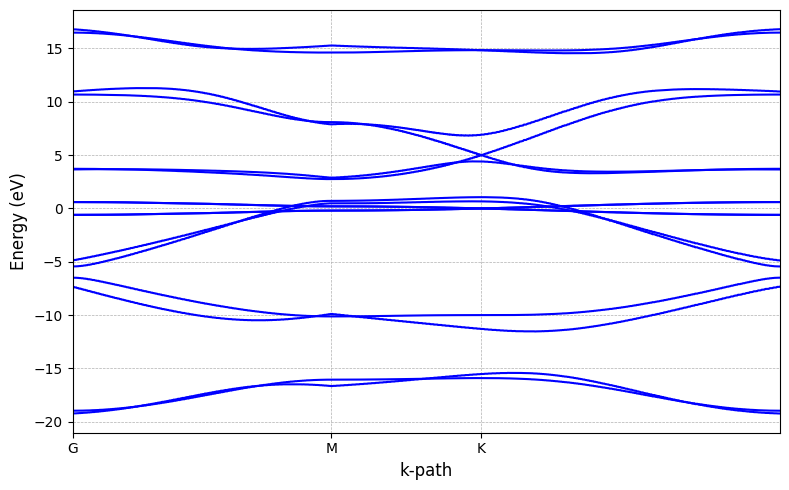

In [33]:
tb_bulk.plot_band_structure(g)

# Z2 Invariant

In [37]:
bands= [14, 15]
wf = problem.hamiltonian["bulk"]["topological_invariants"]
Z_2 = wf.Z2_invariant(bands)
print("")
print(f"Z2 = {Z_2}")

Calculating Z2 Invariant...
Z2 Invariant - Done!

Z2 = 1


In [35]:
from pfapack import pfaffian as pf
O = tb_bulk.O # Time-Reversal Operator
U_k = tb_bulk.U_k_dict
kx, ky = g.kx_bulk, g.ky_bulk
trims = g.trims
deltas = []
delta_dict = {}
for k in trims:
    i = np.argmin(np.abs(g.kx_bulk - k[0]))
    j = np.argmin(np.abs(g.ky_bulk - k[1]))
    key = f"[{kx[i]}, {ky[j]}]"
    u_k = U_k[key][:, bands]
    w_k = u_k.conj().T @ O @ u_k.conj()
    w_k_det = np.linalg.det(w_k)
    P_k = pf.pfaffian(w_k)
    delta_i = np.sqrt(w_k_det) / P_k
    delta_dict[f"{k}"] = delta_i
    deltas.append(np.sign(delta_i.real))
total_product = np.prod(deltas)
Z_2 = int((1 - total_product) / 2) # maps +1 to 0, −1 to 1
print(f"Z2 Invariant - Done!")

Z2 Invariant - Done!


In [36]:
delta_dict

{'[0. 0.]': np.complex128(1+0j),
 '[1.04719755 1.81379936]': np.complex128(-1-1.98024977959006e-17j),
 '[ 1.04719755 -1.81379936]': np.complex128(0.9999999999999998+7.644104254153869e-17j),
 '[2.0943951 0.       ]': np.complex128(0.9999999999999999+0j)}